# Chapter 12 — Linear Regression and Correlation

Fitting a line, reading r, and knowing when prediction is safe.

| Section | What it covers |
|---|---|
| 12.1 | Least squares |
| 12.2 | Correlation |
| 12.3 | The line is an estimate |
| 12.4 | Prediction and outliers |

**How to use this notebook.** Read a short explanation, run the worked cell under it, then do the
**Your turn** cell yourself. The worked cells already show their output, so you can check your
answer against them. Nothing here is graded and nothing is hidden, so break things freely and
re-run the setup cell if you get lost.

The matching page on the website is [Linear Regression and Correlation](https://khh-aka-lucifer.github.io/statLab/chapters/linear-regression/), where the same ideas are
sliders and draggable points instead of code. Use both. The website builds the intuition, and the
notebook shows you how to do it to data of your own.

In [1]:
# Run me first. Everything below needs this cell.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# The same colours the StatLab website uses, so your charts match the demos.
C = {
    "accent": "#2E7D6B", "accent_strong": "#1F5A4D", "accent_soft": "#D9EBE5",
    "ink": "#282725", "ink_soft": "#6B6560", "line": "#E4E0DA",
    "cat1": "#2E7D6B", "cat2": "#B5763F", "cat3": "#4E7DA6",
    "cat4": "#9A5D8F", "cat5": "#8A8F3C",
    "ok": "#4C8B57", "warn": "#C06A2E",
}

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": C["line"], "axes.labelcolor": C["ink"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C["line"], "grid.linewidth": 0.8,
    "text.color": C["ink"], "xtick.color": C["ink_soft"], "ytick.color": C["ink_soft"],
    "font.size": 11, "axes.titlesize": 12, "legend.frameon": False,
})

# Works whether you launched Jupyter inside code/ or at the repo root.
DATA = Path("data") if Path("data").exists() else Path("code/data")

# One seed, so your numbers match the text. Change it and the randomness changes with you.
rng = np.random.default_rng(12345)

print("Ready. pandas", pd.__version__, "| numpy", np.__version__)

Ready. pandas 3.0.3 | numpy 2.4.4


## Money and years of life

Gapminder records life expectancy and income for 142 countries. Take the most recent year in the
file, 2007, and ask the obvious question: do richer countries live longer, and by how much?

In [2]:
gap = pd.read_csv(DATA / "gapminder.csv")
world = gap[gap["year"] == 2007].copy()

print(f"{len(world)} countries in 2007")
world[["country", "continent", "lifeExp", "gdpPercap"]].head()

142 countries in 2007


,country,continent,lifeExp,gdpPercap
11,Afghanistan,Asia,43.828,974.580338
23,Albania,Europe,76.423,5937.029526
35,Algeria,Africa,72.301,6223.367465
47,Angola,Africa,42.731,4797.231267
59,Argentina,Americas,75.320,12779.379640


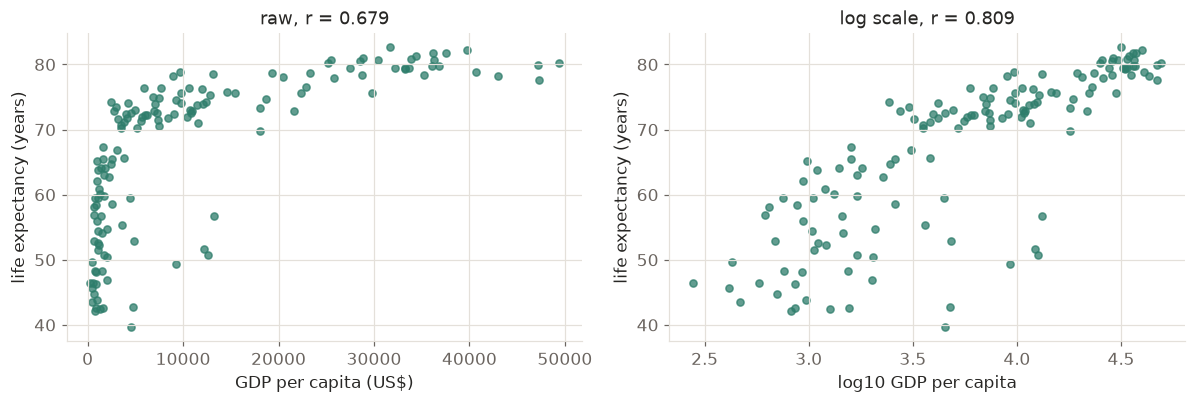

In [3]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

left.scatter(world["gdpPercap"], world["lifeExp"], s=22, color=C["accent"], alpha=0.75)
left.set_xlabel("GDP per capita (US$)"); left.set_ylabel("life expectancy (years)")
left.set_title(f"raw, r = {np.corrcoef(world['gdpPercap'], world['lifeExp'])[0,1]:.3f}")

world["log_gdp"] = np.log10(world["gdpPercap"])
right.scatter(world["log_gdp"], world["lifeExp"], s=22, color=C["accent"], alpha=0.75)
right.set_xlabel("log10 GDP per capita"); right.set_ylabel("life expectancy (years)")
right.set_title(f"log scale, r = {np.corrcoef(world['log_gdp'], world['lifeExp'])[0,1]:.3f}")

plt.tight_layout()
plt.show()

The raw plot bends. Going from $500 to $5000 a year buys a great deal of life, and going from
$35,000 to $40,000 buys almost none. That is a curve, and a straight line fitted to it would be a
poor description.

On a log scale the same data straightens out, and the correlation rises from 0.68 to 0.81. The log
is not a trick to inflate a number. It changes the question from "what does an extra dollar buy" to
"what does an extra *percentage* of income buy", which is the sensible question about income.

We work in log dollars from here.

## 12.1 Least squares

A straight line $\hat{y} = a + bx$ predicts a $y$ for every $x$. Each point misses by its
**residual**, $y_i - \hat{y}_i$. The **least-squares line** is the one line that makes the sum of the
squared residuals as small as possible, and its slope and intercept come from the data alone,

$$b = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \qquad a = \bar{y} - b\bar{x}$$

In [4]:
x = world["log_gdp"].to_numpy()
y = world["lifeExp"].to_numpy()

# by hand, straight from the formula
b = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean())**2).sum()
a = y.mean() - b * x.mean()

fit = stats.linregress(x, y)

print(f"by hand : intercept {a:8.3f}   slope {b:7.3f}")
print(f"scipy   : intercept {fit.intercept:8.3f}   slope {fit.slope:7.3f}")
print()
print(f"So each tenfold increase in income is worth about {b:.1f} years of life expectancy.")

by hand : intercept    4.950   slope  16.585
scipy   : intercept    4.950   slope  16.585

So each tenfold increase in income is worth about 16.6 years of life expectancy.


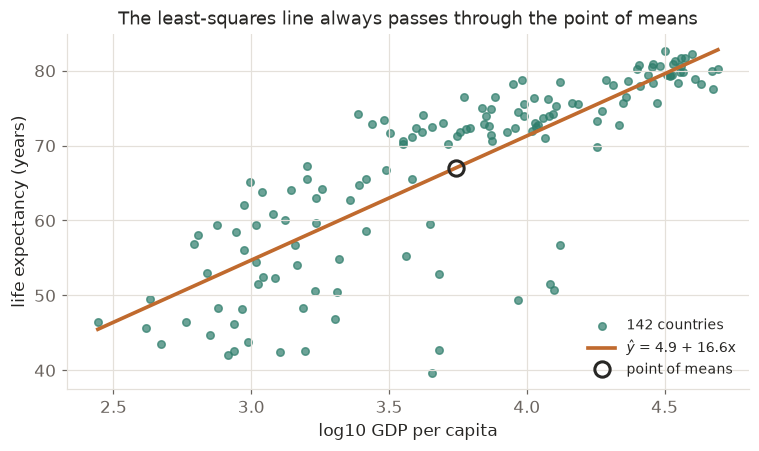

In [5]:
line_x = np.linspace(x.min(), x.max(), 100)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(x, y, s=24, color=C["accent"], alpha=0.7, label="142 countries")
ax.plot(line_x, a + b*line_x, color=C["warn"], lw=2.4,
        label=rf"$\hat{{y}}$ = {a:.1f} + {b:.1f}x")
ax.plot(x.mean(), y.mean(), "o", color=C["ink"], ms=10, mfc="none", mew=2,
        label="point of means")

ax.set_xlabel("log10 GDP per capita"); ax.set_ylabel("life expectancy (years)")
ax.set_title("The least-squares line always passes through the point of means")
ax.legend(loc="lower right", fontsize=9)
plt.show()

Now prove that "least squares" is not just a name. Nudge the slope or the intercept in any direction
and the sum of squared residuals gets worse.

In [6]:
def sse(intercept, slope):
    return ((y - (intercept + slope * x))**2).sum()

best = sse(a, b)
print(f"the fitted line          SSE = {best:.2f}")
for da, db, label in [(0, 0.5, "slope + 0.5"), (0, -0.5, "slope - 0.5"),
                      (2, 0, "intercept + 2"), (-2, 0, "intercept - 2")]:
    print(f"{label:16s}         SSE = {sse(a+da, b+db):.2f}   (worse by {sse(a+da, b+db)-best:.2f})")

the fitted line          SSE = 7101.71
slope + 0.5              SSE = 7610.97   (worse by 509.26)
slope - 0.5              SSE = 7610.97   (worse by 509.26)
intercept + 2            SSE = 7669.71   (worse by 568.00)
intercept - 2            SSE = 7669.71   (worse by 568.00)


In [ ]:
# Your turn.
# Fit a least-squares line to the cars data: mpg against weight.
# 1. Compute the slope and intercept by hand and check against stats.linregress.
# 2. What does the slope mean in words, with units?
# 3. Would a log transform help here? Plot it and decide.

cars = pd.read_csv(DATA / "cars.csv")
...

## 12.2 Correlation

The **correlation coefficient** $r$ measures how tightly the points hug a straight line. It runs from
$-1$ to $1$, and its square, $r^2$, is the share of the variation in $y$ that the line explains.

The thing to understand about $r$ is what it does *not* measure. It does not measure steepness, and
it does not detect curves.

In [7]:
r = np.corrcoef(x, y)[0, 1]
print(f"r  = {r:.4f}")
print(f"r2 = {r**2:.4f}   so the line explains {r**2:.1%} of the variation in life expectancy")
print()
print(f"scipy agrees: r = {fit.rvalue:.4f}, r2 = {fit.rvalue**2:.4f}")

r  = 0.8090
r2 = 0.6544   so the line explains 65.4% of the variation in life expectancy

scipy agrees: r = 0.8090, r2 = 0.6544


In [8]:
# r is blind to the scale of either axis
print("r is unchanged when you rescale:")
print(f"  original                      r = {np.corrcoef(x, y)[0,1]:.4f}")
print(f"  life expectancy in months     r = {np.corrcoef(x, y*12)[0,1]:.4f}")
print(f"  log income shifted by +100    r = {np.corrcoef(x+100, y)[0,1]:.4f}")
print()
print("but the SLOPE changes completely:")
print(f"  original slope                {stats.linregress(x, y).slope:.3f} years per log-dollar")
print(f"  in months                     {stats.linregress(x, y*12).slope:.3f} months per log-dollar")

r is unchanged when you rescale:
  original                      r = 0.8090
  life expectancy in months     r = 0.8090
  log income shifted by +100    r = 0.8090

but the SLOPE changes completely:
  original slope                16.585 years per log-dollar
  in months                     199.021 months per log-dollar


### Where r misleads

Here is the standard warning, made concrete. A perfect parabola has a correlation of essentially
zero, because $r$ only sees straight-line association.

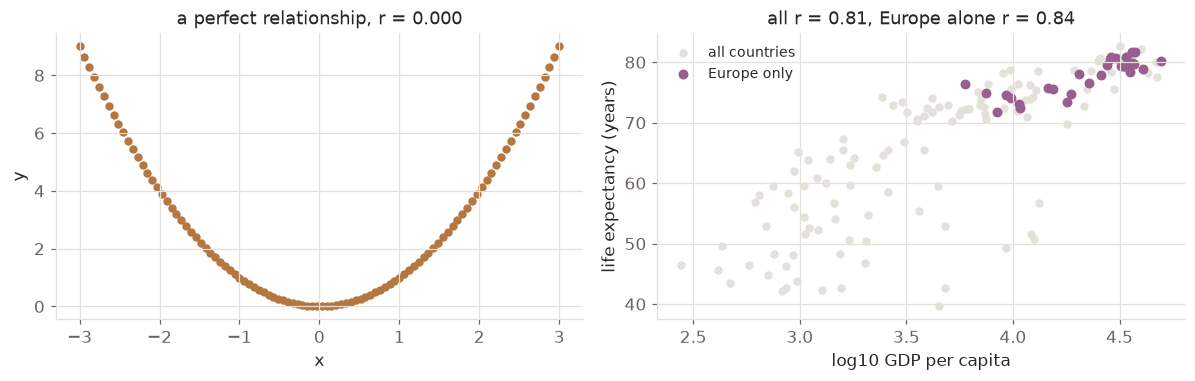

In [9]:
curve_x = np.linspace(-3, 3, 100)
curve_y = curve_x**2

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))

left.scatter(curve_x, curve_y, s=20, color=C["cat2"])
left.set_title(f"a perfect relationship, r = {np.corrcoef(curve_x, curve_y)[0,1]:.3f}")
left.set_xlabel("x"); left.set_ylabel("y")

# and a real one: within a continent, the relationship is much weaker
europe = world[world["continent"] == "Europe"]
right.scatter(world["log_gdp"], world["lifeExp"], s=20, color=C["line"], label="all countries")
right.scatter(europe["log_gdp"], europe["lifeExp"], s=30, color=C["cat4"], label="Europe only")
right.set_title(f"all r = {r:.2f}, Europe alone r = "
                f"{np.corrcoef(europe['log_gdp'], europe['lifeExp'])[0,1]:.2f}")
right.set_xlabel("log10 GDP per capita"); right.set_ylabel("life expectancy (years)")
right.legend(fontsize=9)

plt.tight_layout()
plt.show()

The right panel is the more important warning. Across all 142 countries $r$ is 0.81. Within Europe
alone it drops to 0.54, because Europe covers a narrow slice of the income range. Restricting the
range of $x$ shrinks $r$ even when the underlying relationship has not changed at all.

And the obvious point, which needs saying anyway: none of this shows that money *causes* longer
life. Richer countries also have better sanitation, more doctors and fewer wars, and the data cannot
separate those.

In [ ]:
# Your turn.
# 1. Compute r between log_gdp and lifeExp separately for each continent.
# 2. Which continent has the strongest relationship, and which the weakest?
# 3. Does the continent with the weakest r have the narrowest income range? Check.

...

## 12.3 The line is an estimate

The slope you computed came from one set of 142 countries. Another set would give a different slope.
The slope is a statistic with a sampling distribution, exactly like a sample mean.

Since we cannot collect another planet, we resample this one, which is a preview of Chapter 16.

In [10]:
slopes = []
for _ in range(2000):
    pick = rng.integers(0, len(x), len(x))          # resample countries with replacement
    slopes.append(stats.linregress(x[pick], y[pick]).slope)
slopes = np.array(slopes)

print(f"fitted slope        {b:.3f}")
print(f"resampled mean      {slopes.mean():.3f}")
print(f"resampled sd        {slopes.std(ddof=1):.3f}   <- the standard error of the slope")
print(f"scipy's formula SE  {fit.stderr:.3f}")
print()
print(f"95% interval for the slope: ({np.percentile(slopes, 2.5):.2f}, {np.percentile(slopes, 97.5):.2f})")

fitted slope        16.585
resampled mean      16.583
resampled sd        0.768   <- the standard error of the slope
scipy's formula SE  1.019



95% interval for the slope: (15.04, 18.03)


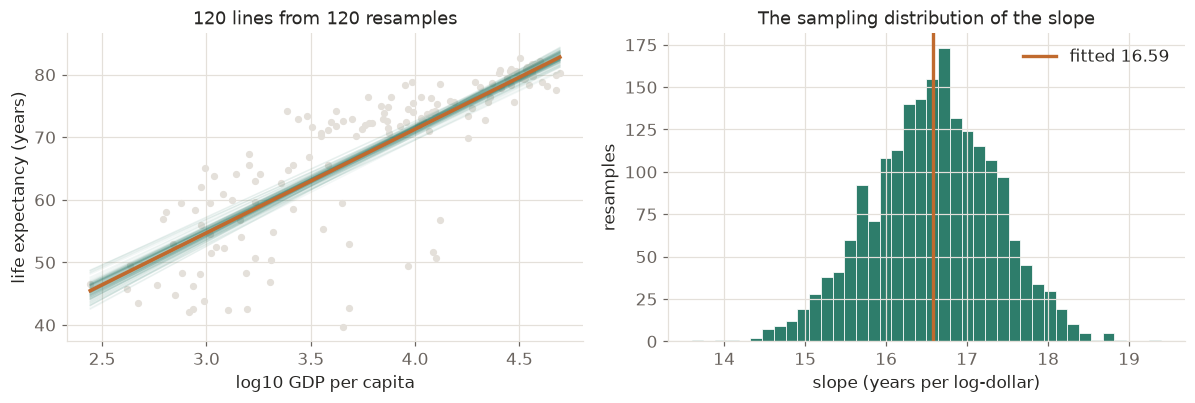

In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.8))

for _ in range(120):
    pick = rng.integers(0, len(x), len(x))
    f = stats.linregress(x[pick], y[pick])
    left.plot(line_x, f.intercept + f.slope*line_x, color=C["accent"], alpha=0.06, lw=1)
left.scatter(x, y, s=14, color=C["line"], zorder=0)
left.plot(line_x, a + b*line_x, color=C["warn"], lw=2.4)
left.set_xlabel("log10 GDP per capita"); left.set_ylabel("life expectancy (years)")
left.set_title("120 lines from 120 resamples")

right.hist(slopes, bins=40, color=C["accent"], edgecolor="white", linewidth=0.5)
right.axvline(b, color=C["warn"], lw=2.2, label=f"fitted {b:.2f}")
right.set_xlabel("slope (years per log-dollar)"); right.set_ylabel("resamples")
right.set_title("The sampling distribution of the slope"); right.legend()

plt.tight_layout()
plt.show()

The band of lines is narrow in the middle and fans out at the ends, which is the picture behind every
regression confidence band you have ever seen. Prediction is most precise near the centre of your
data and least precise at the edges.

In [ ]:
# Your turn.
# Repeat the resampling with only 30 countries at a time instead of all 142.
# 1. How much wider is the band of slopes?
# 2. Is the widening consistent with the 1/sqrt(n) rule from Chapter 7?

...

## 12.4 Prediction and outliers

A fitted line will happily predict a $y$ for any $x$ you give it, including values the data knows
nothing about. Inside the observed range that is **interpolation**. Outside it is **extrapolation**,
and the line has no authority there at all.

In [12]:
def predict(value):
    return a + b * value

for gdp in [1000, 10_000, 40_000, 1_000_000]:
    lx = np.log10(gdp)
    inside = x.min() <= lx <= x.max()
    print(f"GDP ${gdp:>9,}  ->  predicted life expectancy {predict(lx):6.1f} years"
          f"   {'(interpolation)' if inside else '(EXTRAPOLATION, not to be trusted)'}")

print(f"\nthe data only covers ${10**x.min():,.0f} to ${10**x.max():,.0f}")

GDP $    1,000  ->  predicted life expectancy   54.7 years   (interpolation)
GDP $   10,000  ->  predicted life expectancy   71.3 years   (interpolation)
GDP $   40,000  ->  predicted life expectancy   81.3 years   (interpolation)
GDP $1,000,000  ->  predicted life expectancy  104.5 years   (EXTRAPOLATION, not to be trusted)

the data only covers $278 to $49,357


A million dollars a year predicts 100 years of life expectancy, which is nonsense. Nothing in the
arithmetic stopped us, and nothing ever will. Checking the range is your job.

### Influential points

One point in an unusual place can steer the whole line. The measure of "unusual place" is
**leverage**, which is about the $x$ value, not the $y$ value.

In [13]:
# find the countries whose removal moves the slope most
effects = []
for i, country in enumerate(world["country"].to_numpy()):
    keep = np.arange(len(x)) != i
    effects.append({"country": country,
                    "slope without it": stats.linregress(x[keep], y[keep]).slope,
                    "x distance from mean": abs(x[i] - x.mean())})

effects = pd.DataFrame(effects)
effects["shift"] = (effects["slope without it"] - b).abs()
effects.nlargest(6, "shift")[["country", "slope without it", "shift", "x distance from mean"]].round(3)

,country,slope without it,shift,x distance from mean
86,Mozambique,16.391,0.194,0.826
112,Sierra Leone,16.399,0.186,0.806
140,Zambia,16.399,0.186,0.638
73,Lesotho,16.411,0.174,0.546
0,Afghanistan,16.417,0.168,0.753
26,Comoros,16.749,0.164,0.748


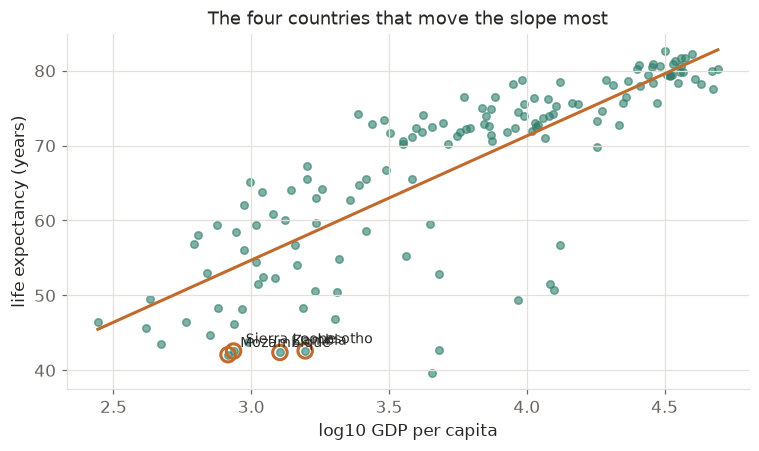

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(x, y, s=24, color=C["accent"], alpha=0.6)

top = effects.nlargest(4, "shift")
for _, row in top.iterrows():
    i = world.index[world["country"] == row["country"]][0]
    ax.scatter(world.loc[i, "log_gdp"], world.loc[i, "lifeExp"], s=90, facecolor="none",
               edgecolor=C["warn"], lw=2)
    ax.annotate(row["country"], (world.loc[i, "log_gdp"], world.loc[i, "lifeExp"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9, color=C["ink"])

ax.plot(line_x, a + b*line_x, color=C["warn"], lw=2)
ax.set_xlabel("log10 GDP per capita"); ax.set_ylabel("life expectancy (years)")
ax.set_title("The four countries that move the slope most")
plt.show()

These are the countries that sit far from the average income *and* far off the line. Look them up.
Several are oil states with high income and lower life expectancy than their wealth suggests, which
is a real finding rather than a data error, and that distinction matters. An outlier is not
automatically a mistake to be deleted.

The residual plot is the standard way to check whether a line was the right shape at all.

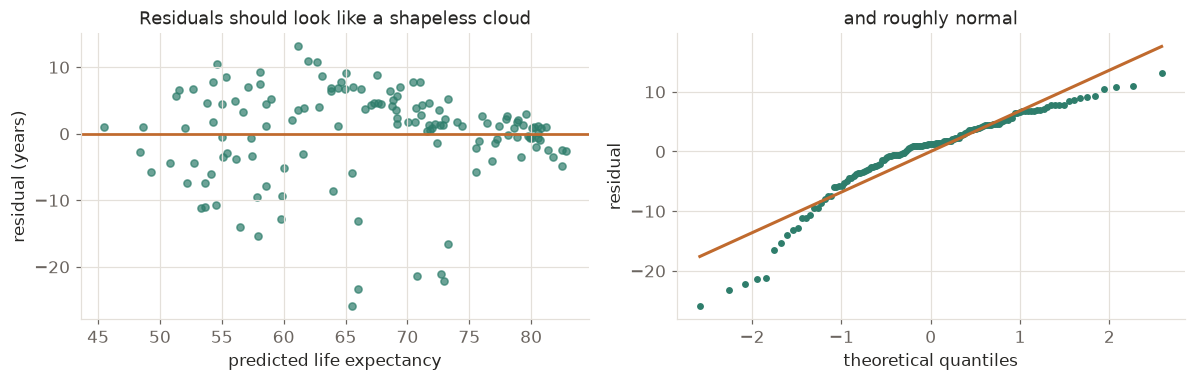

residuals: mean -1.00e-15 (always zero), sd 7.10 years


In [15]:
residuals = y - (a + b*x)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6))

left.scatter(a + b*x, residuals, s=22, color=C["accent"], alpha=0.7)
left.axhline(0, color=C["warn"], lw=1.8)
left.set_xlabel("predicted life expectancy"); left.set_ylabel("residual (years)")
left.set_title("Residuals should look like a shapeless cloud")

stats.probplot(residuals, dist="norm", plot=right)
right.get_lines()[0].set(color=C["accent"], marker="o", markersize=3.5)
right.get_lines()[1].set(color=C["warn"], linewidth=2)
right.set_title("and roughly normal")
right.set_xlabel("theoretical quantiles"); right.set_ylabel("residual")

plt.tight_layout()
plt.show()

print(f"residuals: mean {residuals.mean():.2e} (always zero), sd {residuals.std(ddof=1):.2f} years")

In [ ]:
# Your turn.
# Use the cars data. Fit mpg against horsepower.
# 1. Draw the residual plot. It will show an obvious curve.
# 2. What does that curve tell you about using a straight line here?
# 3. Try fitting mpg against log10(horsepower) and draw the residuals again. Better?

cars = pd.read_csv(DATA / "cars.csv").dropna(subset=["horsepower", "mpg"])
...

## Exercises

1. **Regression to the mean.** Fit life expectancy in 2007 against life expectancy in 1982 for the
   same countries. The slope will be less than 1. Explain what that means, and why it is not evidence
   that countries are converging.

2. **Two ways to get r.** Confirm that $r$ equals the slope of the line fitted to the standardised
   $x$ and $y$, and that $r^2$ equals 1 minus the ratio of residual variance to total variance.

3. **Anscombe's quartet.** Look it up, type in the four small data sets, and confirm they share a
   mean, a variance, a correlation and a regression line while looking nothing alike. It is the best
   single argument for plotting your data.

4. **Prediction intervals.** A confidence interval for the *line* is narrower than a prediction
   interval for a *new country*. Build both at $x = 4$ by resampling and compare their widths.
   Explain the difference in one sentence.

5. **Continent as a third variable.** Fit the line separately for each continent, plot all five, and
   compare them against the pooled line. This is Chapter 17 knocking.

## What you should take away

Least squares finds the one line that minimises squared residuals, and you verified it is a minimum
by nudging it. The line always passes through the point of means.

$r$ measures tightness, not steepness, and it is blind to curves and sensitive to how wide a range of
$x$ you sampled. The slope is an estimate with its own sampling distribution, which you built by
resampling. And a fitted line will extrapolate to absurdity without complaint, so checking the range
of your data before predicting is entirely your responsibility.

---

*StatLab, by Dr. Sein Minn and Kaung Hein Htet. Code MIT, text CC BY 4.0.
Follows OpenStax [Introductory Statistics](https://openstax.org) (Illowsky & Dean, CC BY 4.0).*